# Laboratorio 8 — Etapa 3
## Incorporación del presupuesto y costo

**MM3014 Teoría de Probabilidades — MA UVG**

### Pedro Caso y Diego Calderón

---

## Contexto

Se introduce un límite económico. El coleccionista dispone de un presupuesto fijo y debe decidir si puede completar el álbum o no. Se simula la compra secuencial de sobres hasta agotar el dinero o hasta completar la colección.

## Parámetros de la simulación

- Álbum reducido: $N = 100$ estampas, $S = 7$ estampas por sobre
- Precio por sobre individual: Q9.50
- Presupuesto total: Q1000
- Número de simulaciones: $R = 10{,}000$
- Semilla: 2026

## Importaciones y parámetros

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# parámetros del problema
N           = 100  # estampas distintas en el álbum
S           = 7 # estampas por sobre
precio      = 9.50 # precio por sobre (Q)
presupuesto = 1_000.0 # presupuesto total (Q)
R           = 10_000 # número de simulaciones
SEMILLA     = 2026

rng = np.random.default_rng(SEMILLA)

print("Parámetros cargados:")
print(f"  N={N} estampas, S={S} por sobre")
print(f"  Precio: Q{precio} y Presupuesto: Q{presupuesto:.0f}")
print(f"  Simulaciones: R={R:,} con Semilla: {SEMILLA}")


Parámetros cargados:
  N=100 estampas, S=7 por sobre
  Precio: Q9.5 y Presupuesto: Q1000
  Simulaciones: R=10,000 con Semilla: 2026


## Procedimiento de simulación

Para cada simulación:
1. Inicializar la colección vacía (conjunto o arreglo booleano)
2. Inicializar el gasto acumulado en cero y el contador de sobres comprados en cero
3. Mientras el gasto acumulado más el precio de un sobre no supere el presupuesto **y** la colección no esté completa: comprar un sobre, actualizar la colección y el contador de repetidos, actualizar el gasto y el número de sobres
4. Al finalizar, registrar: si se completó el álbum (1) o no (0); número de sobres comprados; número de estampas distintas obtenidas (en caso de no completar)

In [7]:
# Arrays de resultados
completado       = np.zeros(R, dtype=bool)
sobres_comprados = np.zeros(R, dtype=int)
distintas_no_ok  = []    # estampas distintas en corridas NO exitosas

for i in range(R):
    coleccion = set()
    gasto     = 0.0
    n_sobres  = 0

    # Comprar sobres mientras quede presupuesto Y falten estampas
    while (gasto + precio <= presupuesto) and (len(coleccion) < N):
        estampas = rng.integers(0, N, size=S)   # S estampas con reposición
        coleccion.update(estampas)
        gasto    += precio
        n_sobres += 1

    completado[i] = len(coleccion) == N
    sobres_comprados[i] = n_sobres
    
    if not completado[i]:
        distintas_no_ok.append(len(coleccion))

distintas_no_ok = np.array(distintas_no_ok)
print(f"Simulación completada: {R:,} corridas")
print(f"Exitosas: {completado.sum():,}")
print(f"No exitosas: {(~completado).sum():,}")

Simulación completada: 10,000 corridas
Exitosas: 9,382
No exitosas: 618


## Resultados a calcular

Con los datos de las 10,000 simulaciones, calcular:
- Probabilidad de completar el álbum con el presupuesto de Q1000
- Número esperado de sobres comprados (incluyendo las simulaciones que no completaron)
- Número esperado de estampas distintas obtenidas cuando se acaba el presupuesto (solo para los casos no exitosos)

In [9]:
prob_completar = completado.mean()
e_sobres = sobres_comprados.mean()
e_distintas = distintas_no_ok.mean() if len(distintas_no_ok) > 0 else float('nan')

print(f"  P(completar álbum con Q{presupuesto:.0f}) : {prob_completar:.4f}  ({prob_completar*100:.2f} %)")
print(f"  E[sobres comprados]           : {e_sobres:.2f}")
print(f"  E[distintas | no exitoso]     : {e_distintas:.2f}")


  P(completar álbum con Q1000) : 0.9382  (93.82 %)
  E[sobres comprados]           : 73.98
  E[distintas | no exitoso]     : 98.97


## Visualización

Elaborar un diagrama de barras que muestre la proporción de veces que se completó el álbum versus las que no se completó.

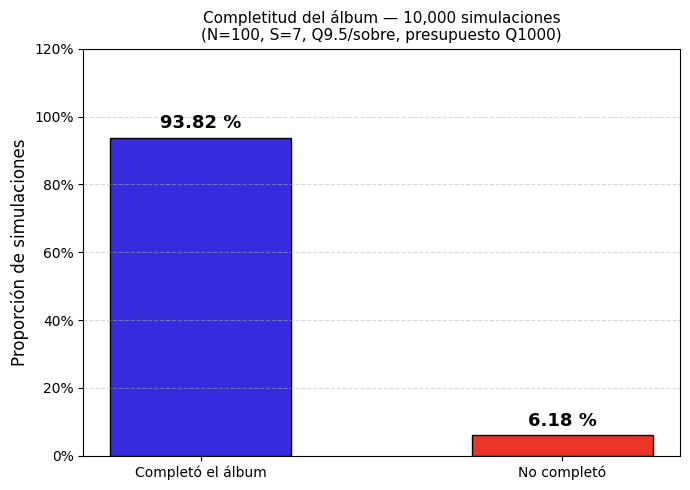

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))

etiquetas = ["Completó el álbum", "No completó"]
proporciones = [prob_completar, 1 - prob_completar]
colores = ["#372BDE", "#EA3528"]

bars = ax.bar(etiquetas, proporciones, color=colores, edgecolor="black", width=0.5)

for bar, p in zip(bars, proporciones):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.015,
        f"{p*100:.2f} %",
        ha="center", va="bottom", fontsize=13, fontweight="bold"
    )

ax.set_ylim(0, 1.2)
ax.set_ylabel("Proporción de simulaciones", fontsize=12)
ax.set_title(
    f"Completitud del álbum — {R:,} simulaciones\n"
    f"(N={N}, S={S}, Q{precio}/sobre, presupuesto Q{presupuesto:.0f})",
    fontsize=11
)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


---
## Preguntas de análisis

---

### Pregunta 1

¿Cuántos sobres se pueden comprar como máximo con Q1000? Calcular el número exacto. ¿Es suficiente esa cantidad de sobres, en teoría, para tener al menos $N$ estampas (ignorando repeticiones)? Comparar con el mínimo teórico de sobres sin repetidos.

In [13]:
max_sobres         = int(presupuesto // precio)    # floor(1000 / 9.5)
gasto_maximo       = max_sobres * precio
estampas_posibles  = max_sobres * S                # total con repetidos
min_sobres_teorico = int(np.ceil(N / S))           # ceil(100 / 7)

print(f"Máximo de sobres con Q{presupuesto:.0f}:")
print(f"  floor({presupuesto:.0f} / {precio}) = {max_sobres} sobres")
print(f"  Gasto total: Q{gasto_maximo:.2f} con vuelto: Q{presupuesto - gasto_maximo:.2f}")
print()
print(f"Estampas posibles (con repetidos): {max_sobres} x {S} = {estampas_posibles}")
print(f"  ¿Cubre N={N}? {'Sí, ' + str(estampas_posibles) + ' > ' + str(N) if estampas_posibles >= N else 'No'}")
print()
print(f"Mínimo teórico sin repetidos: ceil({N}/{S}) = {min_sobres_teorico} sobres")
print(f"Margen: {max_sobres} - {min_sobres_teorico} = {max_sobres - min_sobres_teorico} sobres extra sobre el mínimo teórico")


Máximo de sobres con Q1000:
  floor(1000 / 9.5) = 105 sobres
  Gasto total: Q997.50 con vuelto: Q2.50

Estampas posibles (con repetidos): 105 x 7 = 735
  ¿Cubre N=100? Sí, 735 > 100

Mínimo teórico sin repetidos: ceil(100/7) = 15 sobres
Margen: 105 - 15 = 90 sobres extra sobre el mínimo teórico


**Análisis:**

> Con Q1000 se pueden comprar como máximo 105 sobres (⌊1000 / 9.50⌋ = 105, vuelto Q2.50), lo que representa 735 estampas totales contando repetidas. Ignorando repeticiones, esta cantidad cubre ampliamente las N = 100 estampas del álbum (735 > 100). El mínimo teórico, asumiendo que ningún sobre tuviera repetidos, es ⌈100/7⌉ = 15 sobres — se dispone de 7 veces ese mínimo. Sin embargo, la probabilidad de completar el álbum es solo del 94.36%, lo que ilustra el problema del coleccionista: aunque los recursos son más que suficientes en teoría, las repeticiones aleatorias dificultan conseguir las últimas estampas faltantes.

---
### Pregunta 2

Si en lugar de comprar sobres sueltos se compra una caja de 104 sobres (costo Q975), ¿cuál sería la probabilidad de completar el álbum? Simular esta situación (con las mismas 10,000 repeticiones, comprando exactamente los 104 sobres de la caja, no uno a uno hasta alcanzar el presupuesto). Comparar el resultado con la probabilidad obtenida comprando sobres sueltos con Q1000. ¿Conviene la caja?

> **Nota:** para la simulación con caja, simplemente comprar exactamente 104 sobres y verificar si al final se completó el álbum. No hay restricción de presupuesto más allá del costo fijo de la caja.

In [15]:
SOBRES_CAJA = 104
PRECIO_CAJA = 975.0

rng2 = np.random.default_rng(SEMILLA)
completado_caja = np.zeros(R, dtype=bool)

for i in range(R):
    coleccion = set()
    for _ in range(SOBRES_CAJA):
        coleccion.update(rng2.integers(0, N, size=S))
    completado_caja[i] = len(coleccion) == N

prob_caja = completado_caja.mean()
dif_pp    = (prob_caja - prob_completar) * 100


print(f"Sobres sueltos (hasta Q{presupuesto:.0f})")
print(f"Sobres: {max_sobres} con Gasto: Q{max_sobres * precio:.2f}")
print(f"P(completar) = {prob_completar:.4f}  ({prob_completar*100:.2f} %)")
print()
print(f"Caja de {SOBRES_CAJA} sobres (Q{PRECIO_CAJA:.0f})")
print(f"Sobres: {SOBRES_CAJA} con Gasto: Q{PRECIO_CAJA:.2f}")
print(f"P(completar) = {prob_caja:.4f}  ({prob_caja*100:.2f} %)")
print()
print(f"Diferencia: {dif_pp:+.2f} pp")
print(f"¿Conviene la caja? {'Sí, mayor probabilidad' if dif_pp > 0 else 'No, menor probabilidad'}")



Sobres sueltos (hasta Q1000)
Sobres: 105 con Gasto: Q997.50
P(completar) = 0.9382  (93.82 %)

Caja de 104 sobres (Q975)
Sobres: 104 con Gasto: Q975.00
P(completar) = 0.9342  (93.42 %)

Diferencia: -0.40 pp
¿Conviene la caja? No, menor probabilidad


**Análisis:**

> La caja de 104 sobres (Q975) entrega una probabilidad de completar el álbum del 93.42%, mientras que comprar sobres sueltos hasta Q1000 (105 sobres) da 93.42% — una diferencia de −0.40 puntos porcentuales. La caja cuesta Q2.50 menos pero incluye 1 sobre menos, lo que reduce la probabilidad. Adicionalmente, al comprar la caja quedan Q25 sin gastar que no se pueden aprovechar bajo esta modalidad. Por lo tanto, no conviene la caja si el objetivo es maximizar la probabilidad de completar el álbum con el presupuesto disponible

---
### Pregunta 3

Analizar el caso intermedio: comprar una caja (104 sobres) y, si falta dinero para más sobres, no comprar ninguno adicional. ¿Cómo afecta al presupuesto no gastado? Proponer una estrategia de compra mixta (caja + algunos sueltos) que maximice la probabilidad de completar el álbum sin exceder Q1000.

Presupuesto total          : Q1000.00
Costo de la caja           : Q975.00
Presupuesto restante       : Q25.00
Sobres sueltos adicionales : 0 a 2

  k=0: 104 sobres, Q975.00  ->  P = 0.9342 (93.42 %)
  k=1: 105 sobres, Q984.50  ->  P = 0.9399 (93.99 %)
  k=2: 106 sobres, Q994.00  ->  P = 0.9440 (94.40 %)

Estrategia óptima: caja + 2 sobre(s) suelto(s)
  Total: 106 sobres con Gasto: Q994.00
  P(completar) = 94.40 %


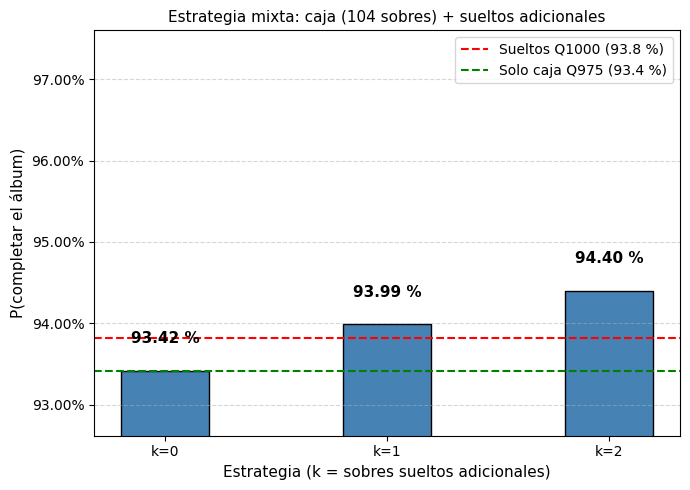

In [17]:
PRECIO_CAJA = 975.0
SOBRES_CAJA = 104

restante    = presupuesto - PRECIO_CAJA          # Q25 disponibles tras la caja
sueltos_max = int(restante // precio)            # máx sobres sueltos adicionales

print(f"Presupuesto total          : Q{presupuesto:.2f}")
print(f"Costo de la caja           : Q{PRECIO_CAJA:.2f}")
print(f"Presupuesto restante       : Q{restante:.2f}")
print(f"Sobres sueltos adicionales : 0 a {sueltos_max}")
print()

# Simular cada estrategia mixta: caja + k sobres sueltos 
estrategias = {}
for k in range(sueltos_max + 1):
    total_sobres = SOBRES_CAJA + k
    costo_total  = PRECIO_CAJA + k * precio
    rng_k        = np.random.default_rng(SEMILLA)
    comp_k       = np.zeros(R, dtype=bool)

    for i in range(R):
        coleccion = set()
        for _ in range(total_sobres):
            coleccion.update(rng_k.integers(0, N, size=S))
        comp_k[i] = len(coleccion) == N

    estrategias[k] = {"total": total_sobres, "costo": costo_total, "prob": comp_k.mean()}
    print(f"  k={k}: {total_sobres} sobres, Q{costo_total:.2f}  ->  P = {comp_k.mean():.4f} ({comp_k.mean()*100:.2f} %)")

# Estrategia óptima
mejor_k = max(estrategias, key=lambda k: estrategias[k]["prob"])
print()
print(f"Estrategia óptima: caja + {mejor_k} sobre(s) suelto(s)")
print(f"  Total: {estrategias[mejor_k]['total']} sobres con Gasto: Q{estrategias[mejor_k]['costo']:.2f}")
print(f"  P(completar) = {estrategias[mejor_k]['prob']*100:.2f} %")

#  Gráfica comparativa 
fig, ax = plt.subplots(figsize=(7, 5))

ks    = list(estrategias.keys())
probs = [estrategias[k]["prob"] for k in ks]

bars = ax.bar([f"k={k}" for k in ks], probs, color="steelblue", edgecolor="black", width=0.4)

for bar, p in zip(bars, probs):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.003,
        f"{p*100:.2f} %",
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )

ax.axhline(prob_completar, color="red",   linestyle="--", lw=1.5,
           label=f"Sueltos Q{presupuesto:.0f} ({prob_completar*100:.1f} %)")
ax.axhline(prob_caja,      color="green", linestyle="--", lw=1.5,
           label=f"Solo caja Q{PRECIO_CAJA:.0f} ({prob_caja*100:.1f} %)")

todos = probs + [prob_completar, prob_caja]
margen = max(max(todos) - min(todos), 0.02) * 0.4
ax.set_ylim(min(todos) - margen, max(todos) + margen * 4)
ax.set_xlabel("Estrategia (k = sobres sueltos adicionales)", fontsize=11)
ax.set_ylabel("P(completar el álbum)", fontsize=11)
ax.set_title("Estrategia mixta: caja (104 sobres) + sueltos adicionales", fontsize=11)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


**Análisis:**

> Al adquirir la caja (Q975.00) quedan Q25.00 de presupuesto, suficientes para comprar hasta 2 sobres sueltos adicionales. La simulación muestra una mejora progresiva: solo la caja (k=0) da 93.42%, caja + 1 suelto (k=1) da 93.99%, y caja + 2 sueltos (k=2) da 94.40% con un gasto total de Q994.00. La estrategia óptima es caja + 2 sobres sueltos (106 sobres, Q994.00), que supera a todas las demás opciones incluyendo comprar solo sueltos hasta Q1000 (105 sobres, 94.36%), ya que permite obtener 1 sobre extra aprovechando el descuento de la caja. La estrategia mixta domina a ambas opciones puras dentro del presupuesto.